In [42]:
import numpy as np
from matplotlib import pyplot as plt

feild = np.load("Data/NDVI_feild.npy")

In [43]:
feild_dims = feild.shape

print(feild_dims)

(17653, 4798)


In [44]:
chunk_dim = 200

chunk_V_bounds = range(0, feild_dims[0], chunk_dim)     # the 0 dimension is the vertical boundary
chunk_H_bounds = range(0, feild_dims[1], chunk_dim)     # the 1 dimension is the horizontal boundary
chunk_bounds = (chunk_V_bounds, chunk_H_bounds)

def pixel_coord_to_chunk_coord(y, x, _chunk_dim=chunk_dim):
    chunk_x = x // _chunk_dim
    chunk_y = y // _chunk_dim
    return chunk_y, chunk_x

def get_chunk(chunk_y, chunk_x, img=feild, _chunk_bounds=chunk_bounds, _chunk_dim=chunk_dim):

    chunk_bounds_y, chunk_bounds_x = _chunk_bounds[0], _chunk_bounds[1]
    start_y, start_x = chunk_bounds_y[chunk_y], chunk_bounds_x[chunk_x]
    end_y, end_x = start_y + _chunk_dim, start_x + _chunk_dim

    img_slice = img[start_y:end_y, start_x:end_x]

    return img_slice

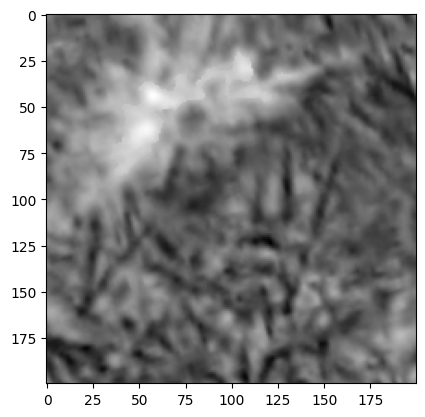

In [47]:
test_chunk = get_chunk(16,6)

plt.imshow(test_chunk, cmap="gray")

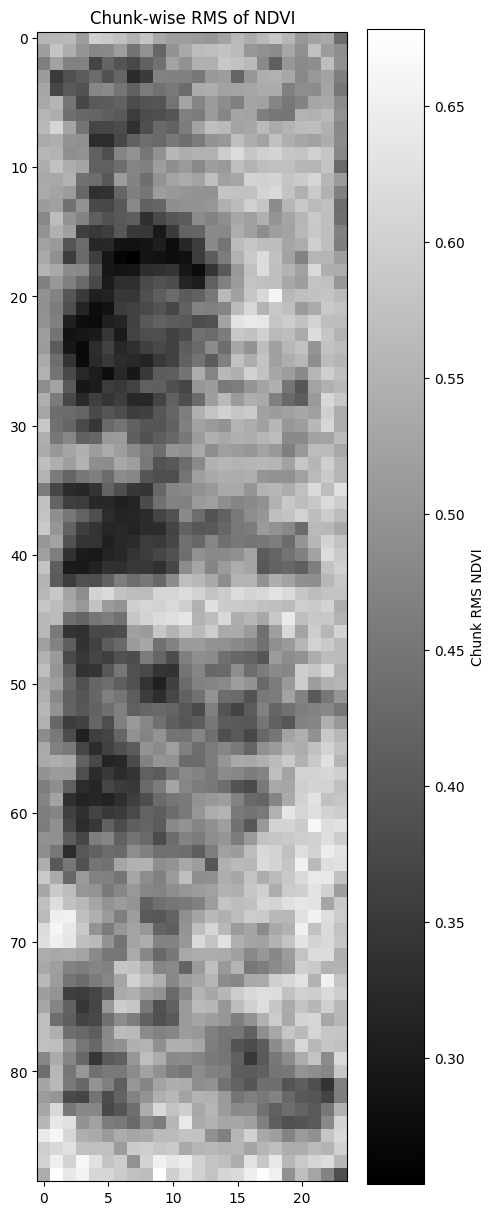

In [46]:
chunks_rms = np.zeros((len(chunk_V_bounds), len(chunk_H_bounds)))

for I, Ibound in enumerate(chunk_V_bounds):
    for J, Jbound in enumerate(chunk_H_bounds):
        chunk = get_chunk(I, J)
        rms = np.sqrt(np.mean(chunk**2))
        chunks_rms[I, J] = rms

plt.figure(figsize=(5,15))
plt.imshow(chunks_rms, cmap='gray')
plt.colorbar(label='Chunk RMS NDVI')
plt.title('Chunk-wise RMS of NDVI')
plt.show()